In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
import keras
import nltk
from tensorflow.keras.layers import Input,SimpleRNN,TextVectorization,LSTM,Embedding,Dense,GRU,Bidirectional
from tensorflow.keras.models import Sequential
#!pip install gensim
#!pip install keras-tuner
from gensim.models import FastText
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
import re
import keras_tuner as ks
from datasets import load_dataset
from warnings import filterwarnings
filterwarnings('ignore')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\suman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
d:\D\adsw\DSA\hvc\hvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Assignment: RNN-Based Text Classification Using AG News Dataset

## Assignment Title 
### Building and Comparing RNN, LSTM, GRU, and Bi-LSTM Models for News Topic Classification

### Task 1: Load and Explore the Dataset

In [2]:
dataset = load_dataset("ag_news")
print(dataset)
print(type(dataset))

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
<class 'datasets.dataset_dict.DatasetDict'>


In [3]:
df_train=pd.DataFrame(dataset['train'])
df_test=pd.DataFrame(dataset['test'])


In [4]:
df_train.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [5]:
from sklearn.model_selection import train_test_split
x_train=df_train['text']
y_train=df_train['label']
x_test=df_test['text']
y_test=df_test['label']

x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.2,shuffle=True)

print(f'x_train shape : {x_train.shape}')
print(f'y_train shape : {y_train.shape}')

print(f'x_val shape : {x_val.shape}')
print(f'y_val shape : {y_val.shape}')

print(f'x_test shape : {x_test.shape}')
print(f'y_test shape : {y_test.shape}')

x_train shape : (96000,)
y_train shape : (96000,)
x_val shape : (24000,)
y_val shape : (24000,)
x_test shape : (7600,)
y_test shape : (7600,)


In [6]:
x_train

152       Cassini Spacecraft Sees Saturn Lightning (AP) ...
75685     Harmony #39;s hostile takeover bid sparks cour...
42699     Organizers Call Off Blue-Gray Classic (AP) AP ...
28805     Cisco joins WiMax Forum com September 15, 2004...
42327     Hamm Argues to Keep Gymnastics Gold (AP) AP - ...
                                ...                        
43126     EVD aims expansion, partnership amid challenge...
104154    Wal-Mart Falls 3 Pct on Forecast Cut  NEW YORK...
83262     Senate can limit Bush plans (Chicago Tribune) ...
52790     Afghan government says drug smugglers were beh...
52215     DNA Crime Bill Passed in House (Reuters) Reute...
Name: text, Length: 96000, dtype: object

In [7]:
for i in range(4):
  print(f'text :{x_train.iloc[i]} \n label :{y_train.iloc[i]}')

text :Cassini Spacecraft Sees Saturn Lightning (AP) AP - The Cassini spacecraft's mission to Saturn has revealed a new radiation belt around the ringed planet and found that lightning in its atmosphere is occurring in different patterns than it did when NASA's Voyagers flew by in the early 1980s, scientists said. 
 label :3
text :Harmony #39;s hostile takeover bid sparks court challenge in South &lt;b&gt;...&lt;/b&gt; JOHANNESBURG : A battle over a hostile takeover bid to create the world #39;s largest gold mining group has spilled over into court, with Gold Fields Limited (GFI) accusing rival Harmony of being in breach of South African criminal laws. 
 label :2
text :Organizers Call Off Blue-Gray Classic (AP) AP - The Blue-Gray All-Star Classic has been called off for the second time in three years because officials couldn't find a corporate sponsor for the Christmas Day showcase for aspiring NFL players. 
 label :1
text :Cisco joins WiMax Forum com September 15, 2004, 12:36 PM PT. Mo

In [8]:
print(f"training unique labels : {y_train.nunique()}")
print(f"testing unique labels : {y_test.nunique()}")
print(f"validation unique labels : {y_val.nunique()}")

training unique labels : 4
testing unique labels : 4
validation unique labels : 4


In [9]:
df_train['label'].value_counts()

label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64

<Axes: xlabel='label'>

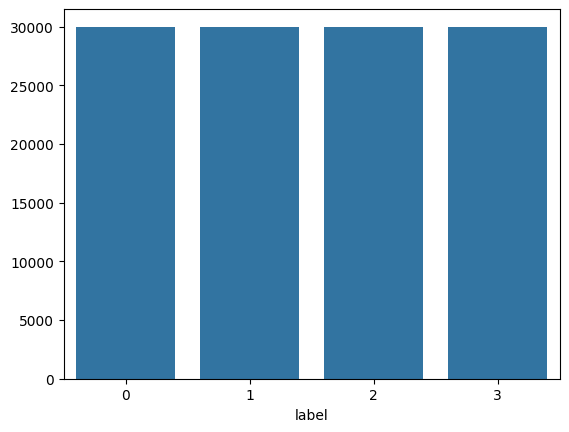

In [10]:
sns.barplot(x=df_train['label'].value_counts().index,y=df_train['label'].value_counts().values)

In [11]:

#tokenization
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^A-Za-z0-9 ]',' ',text)

    return text
tokenized_corpus=[word_tokenize(clean_text(sentence)) for sentence in df_train['text']]
tokenized_corpus[:5]

[['wall',
  'st',
  'bears',
  'claw',
  'back',
  'into',
  'the',
  'black',
  'reuters',
  'reuters',
  'short',
  'sellers',
  'wall',
  'street',
  's',
  'dwindling',
  'band',
  'of',
  'ultra',
  'cynics',
  'are',
  'seeing',
  'green',
  'again'],
 ['carlyle',
  'looks',
  'toward',
  'commercial',
  'aerospace',
  'reuters',
  'reuters',
  'private',
  'investment',
  'firm',
  'carlyle',
  'group',
  'which',
  'has',
  'a',
  'reputation',
  'for',
  'making',
  'well',
  'timed',
  'and',
  'occasionally',
  'controversial',
  'plays',
  'in',
  'the',
  'defense',
  'industry',
  'has',
  'quietly',
  'placed',
  'its',
  'bets',
  'on',
  'another',
  'part',
  'of',
  'the',
  'market'],
 ['oil',
  'and',
  'economy',
  'cloud',
  'stocks',
  'outlook',
  'reuters',
  'reuters',
  'soaring',
  'crude',
  'prices',
  'plus',
  'worries',
  'about',
  'the',
  'economy',
  'and',
  'the',
  'outlook',
  'for',
  'earnings',
  'are',
  'expected',
  'to',
  'hang',
  'ove

In [12]:
for i in range(4):
    print(tokenized_corpus[i])

['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's', 'dwindling', 'band', 'of', 'ultra', 'cynics', 'are', 'seeing', 'green', 'again']
['carlyle', 'looks', 'toward', 'commercial', 'aerospace', 'reuters', 'reuters', 'private', 'investment', 'firm', 'carlyle', 'group', 'which', 'has', 'a', 'reputation', 'for', 'making', 'well', 'timed', 'and', 'occasionally', 'controversial', 'plays', 'in', 'the', 'defense', 'industry', 'has', 'quietly', 'placed', 'its', 'bets', 'on', 'another', 'part', 'of', 'the', 'market']
['oil', 'and', 'economy', 'cloud', 'stocks', 'outlook', 'reuters', 'reuters', 'soaring', 'crude', 'prices', 'plus', 'worries', 'about', 'the', 'economy', 'and', 'the', 'outlook', 'for', 'earnings', 'are', 'expected', 'to', 'hang', 'over', 'the', 'stock', 'market', 'next', 'week', 'during', 'the', 'depth', 'of', 'the', 'summer', 'doldrums']
['iraq', 'halts', 'oil', 'exports', 'from', 'main', 'southern', 'pipel

In [13]:
df_train2=df_train.copy()
df_train2['tokenized']=df_train2['text'].apply(lambda x : (word_tokenize(clean_text(x))))
df_train2['token_length']=df_train2['tokenized'].apply(lambda x : len(x))
df_train2

,text,label,tokenized,token_length
0,Wall St. Bears Claw Back Into the Black (Reute...,2,"[wall, st, bears, claw, back, into, the, black...",24
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,"[carlyle, looks, toward, commercial, aerospace...",39
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,"[oil, and, economy, cloud, stocks, outlook, re...",38
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,"[iraq, halts, oil, exports, from, main, southe...",38
4,"Oil prices soar to all-time record, posing new...",2,"[oil, prices, soar, to, all, time, record, pos...",37
...,...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,"[pakistan, s, musharraf, says, won, t, quit, a...",40
119996,Renteria signing a top-shelf deal Red Sox gene...,1,"[renteria, signing, a, top, shelf, deal, red, ...",61
119997,Saban not going to Dolphins yet The Miami Dolp...,1,"[saban, not, going, to, dolphins, yet, the, mi...",44
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,"[today, s, nfl, games, pittsburgh, at, ny, gia...",70


In [14]:
iqr=df_train2['token_length'].quantile(0.75)+1.5*(df_train2['token_length'].quantile(0.75)-df_train2['token_length'].quantile(0.25))

<Axes: xlabel='token_length', ylabel='Count'>

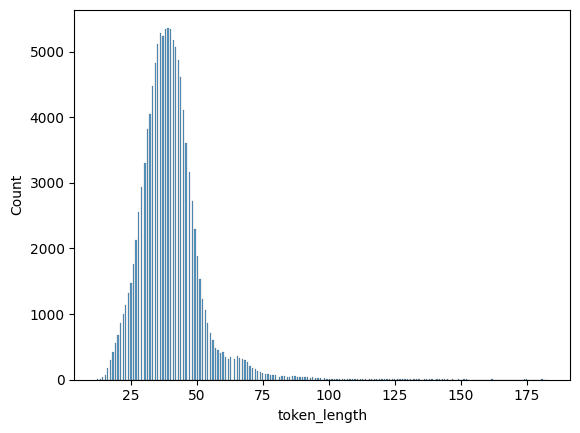

In [15]:
sns.histplot(df_train2['token_length'])

In [16]:
print(df_train2['token_length'].quantile(0.25))
print(df_train2['token_length'].quantile(0.75))

33.0
45.0


In [17]:
max_sentence_len=((int(iqr/10))+1)*10

In [18]:
vectorize_layer=tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=20000,
    output_mode='int',
    output_sequence_length=max_sentence_len,
)

training_sentences=df_train2['text']
vectorize_layer.adapt(training_sentences)

fasttext_model=FastText(sentences=tokenized_corpus,vector_size=100,window=7,min_count=1,workers=4)

vocab=vectorize_layer.get_vocabulary()
num_tokens=len(vocab)
embedding_dim=100
embedding_matrix=np.zeros((num_tokens,embedding_dim))

for i,word in enumerate(vocab):
        embedding_matrix[i]=fasttext_model.wv[word]

In [19]:
x_train_vector=vectorize_layer(x_train).numpy()
x_val_vector=vectorize_layer(x_val).numpy()
x_test_vector=vectorize_layer(x_test).numpy()
y_train_vector=y_train.values
y_val_vector=y_val.values
y_test_vector=y_test.values
print(f"x_train shape : {x_train.shape}")
print(f"x_val shape : {x_val.shape}")
print(f"x_test shape : {x_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape : {y_val.shape}")
print(f"y_test shape : {y_test.shape}")

x_train shape : (96000,)
x_val shape : (24000,)
x_test shape : (7600,)
y_train shape : (96000,)
y_val shape : (24000,)
y_test shape : (7600,)


In [20]:
x_train_vector

array([[2340, 1417,  838, ...,    0,    0,    0],
       [2900,   10, 1470, ...,    0,    0,    0],
       [5551,  660,   99, ...,    0,    0,    0],
       ...,
       [1281,  115, 3271, ...,    0,    0,    0],
       [ 684,   91,   73, ...,    0,    0,    0],
       [2968, 2758,  461, ...,    0,    0,    0]], shape=(96000, 70))

In [21]:
x_train.values

array(["Cassini Spacecraft Sees Saturn Lightning (AP) AP - The Cassini spacecraft's mission to Saturn has revealed a new radiation belt around the ringed planet and found that lightning in its atmosphere is occurring in different patterns than it did when NASA's Voyagers flew by in the early 1980s, scientists said.",
       'Harmony #39;s hostile takeover bid sparks court challenge in South &lt;b&gt;...&lt;/b&gt; JOHANNESBURG : A battle over a hostile takeover bid to create the world #39;s largest gold mining group has spilled over into court, with Gold Fields Limited (GFI) accusing rival Harmony of being in breach of South African criminal laws.',
       "Organizers Call Off Blue-Gray Classic (AP) AP - The Blue-Gray All-Star Classic has been called off for the second time in three years because officials couldn't find a corporate sponsor for the Christmas Day showcase for aspiring NFL players.",
       ...,
       "Senate can limit Bush plans (Chicago Tribune) Chicago Tribune - Despit

#### Brief explanation of why tokenization and padding are needed?
- Tokenization : Raw text cannot be processed directly by neural networks; they only understand
    numbers.it Breaks down raw text into smaller units called tokens (words, subwords, or characters) and maps each token to a unique numerical ID. It creates a standardized vocabulary and allows the model to interpret the text mathematically.

- padding : Deep learning models require batches of data to have a "rectangular" or consistent shape to process them efficiently.it Adds special, meaningless tokens (usually 0) to shorter sentences to match the length of the longest sentence in a batch.Without padding, the model cannot perform matrix multiplication on batches of data, which is necessary for training on GPUs.


### Simple RNN

In [22]:
class SRNN_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      SimpleRNN(units=512,return_sequences=False),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_srnn.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


srnn_model=SRNN_model()
hp=ks.HyperParameters()
srn_model=srnn_model.build(hp)
print(srn_model.summary())

srnn_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=SRNN_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=SRNN_model()
best_hp=tuner.get_best_hyperparameters()[0]
srnn_model=hypermodel.build(best_hp)
srnn_history=hypermodel.fit(best_hp,srnn_model,x_train.values,y_train.values)


srnn_end_time=time.time()
srnn_total_time=(srnn_end_time-srnn_start_time)/60
print(f"total_time_taken: {srnn_total_time}")

Trial 2 Complete [00h 22m 03s]
val_accuracy: 0.8412500023841858

Best val_accuracy So Far: 0.8639166951179504
Total elapsed time: 01h 11m 32s
Epoch 1/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6599 - loss: 1.6712
Epoch 1: val_accuracy improved from 0.01000 to 0.58021, saving model to best_srnn.keras

Epoch 1: finished saving model to best_srnn.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 433s 80ms/step - accuracy: 0.6680 - loss: 1.3188 - val_accuracy: 0.5802 - val_loss: 1.1104
Epoch 2/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7640 - loss: 0.7084
Epoch 2: val_accuracy improved from 0.58021 to 0.82396, saving model to best_srnn.keras

Epoch 2: finished saving model to best_srnn.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 422s 78ms/step - accuracy: 0.7972 - loss: 0.6273 - val_accuracy: 0.8240 - val_loss: 0.5662
Epoch 3/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8331 - loss: 0.5281
Epoch 3: val_accuracy improved from 0.82396 to 0.83042, saving model to 

In [23]:
srnn_train_loss,srnn_train_acc=srnn_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {srnn_train_acc}")
print(f"train Loss: {srnn_train_loss}")

srnn_val_loss,srnn_val_acc=srnn_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {srnn_val_acc}")
print(f"Val Loss: {srnn_val_loss}")

srnn_test_loss,srnn_test_acc=srnn_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {srnn_test_acc}")
print(f"Test Loss: {srnn_test_loss}")

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 130s 42ms/step - accuracy: 0.8257 - loss: 0.5624
Train Accuracy: 0.8256562352180481
train Loss: 0.562402606010437
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.8268 - loss: 0.5580
Val Accuracy: 0.8267916440963745
Val Loss: 0.5580470561981201
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.8243 - loss: 0.5700
Test Accuracy: 0.8243421316146851
Test Loss: 0.570042073726654


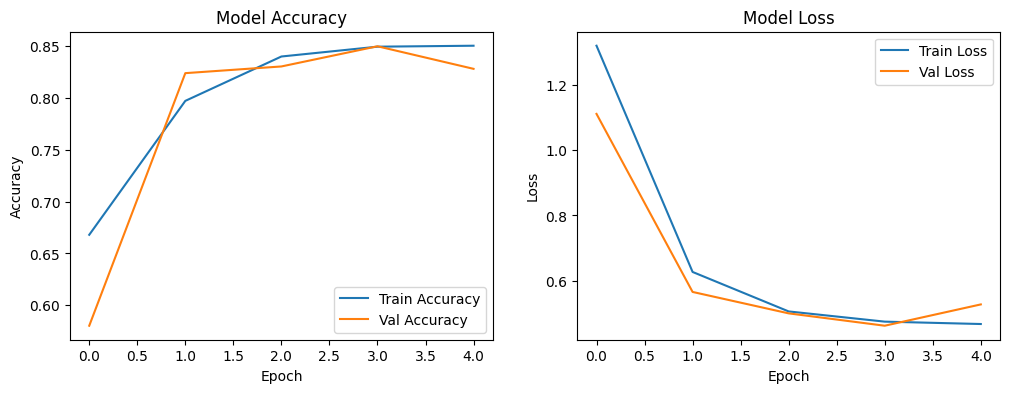

In [24]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(srnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(srnn_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(srnn_history.history['loss'], label='Train Loss')
plt.plot(srnn_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [25]:
from sklearn.metrics import classification_report
srnn_pred=np.argmax(srnn_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,srnn_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step
              precision    recall  f1-score   support

           0       0.75      0.89      0.81      1900
           1       0.90      0.93      0.91      1900
           2       0.83      0.75      0.79      1900
           3       0.83      0.73      0.78      1900

    accuracy                           0.82      7600
   macro avg       0.83      0.82      0.82      7600
weighted avg       0.83      0.82      0.82      7600



In [26]:
comp_table=pd.DataFrame({'metrics':[
                          'Training_Accuracy',
                         'Validation_Accuracy',
                         'Test_Accuracy',
                        'Training_Time(Minutes)',
                          'key Observation']})
comp_table['SimpleRNN']=[srnn_train_acc,srnn_val_acc,srnn_test_acc,srnn_total_time,'']


In [27]:
comp_table

,metrics,SimpleRNN
0,Training_Accuracy,0.825656
1,Validation_Accuracy,0.826792
2,Test_Accuracy,0.824342
3,Training_Time(Minutes),116.522605
4,key Observation,


### KEY_OBSERVATION

In [ ]:
from IPython.display import Markdown, display
display(Markdown(f"""
- Training,Validation,Test Accuracies comes to be 0.82,since on all the the acuuracies coincide,hence chance of overfitting is very very much less.

- Covergence : Training and Validation metrics move's in the same direction showing better generalisation of the model

- model is able to predict class 1 93% of times when is actually class 1 recall(0.93) and out of all predicted as class 1 90% of them is actually class 1,precision(0.90)
        - model is justifying class 1 very well
        - model is justifying class  2 and 3 averagely by predicting them 75% of time as it is recall around 0.75 while out of all predicted as class 2 or 3,it is actually 2 or 3 resp. precision(0.83) 
        - model is justifying class 0 in good way  as having average precision and good recall         


- Time Cost: The training time is recorded at approximately {srnn_total_time}.which is very much for a simple deeplearning model
                 """))

### LSTM

In [ ]:
class LSTM_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      LSTM(units=512,return_sequences=False,dropout=0.2),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_lstm.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


ls_model=LSTM_model()
hp=ks.HyperParameters()
lstm_model=ls_model.build(hp)
print(lstm_model.summary())

lstm_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=LSTM_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=LSTM_model()
best_hp=tuner.get_best_hyperparameters()[0]
lstm_model=hypermodel.build(best_hp)
lstm_history=hypermodel.fit(best_hp,lstm_model,x_train.values,y_train.values)


lstm_end_time=time.time()
lstm_total_time=(lstm_end_time-lstm_start_time)/60
print(f"total_time_taken: {lstm_total_time}")

Trial 2 Complete [01h 24m 53s]
val_accuracy: 0.906333327293396

Best val_accuracy So Far: 0.906333327293396
Total elapsed time: 04h 01m 38s
Epoch 1/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7917 - loss: 2.2221
Epoch 1: val_accuracy improved from 0.01000 to 0.87926, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 608s 3s/step - accuracy: 0.8412 - loss: 1.3563 - val_accuracy: 0.8793 - val_loss: 0.4643
Epoch 2/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8729 - loss: 0.4552
Epoch 2: val_accuracy improved from 0.87926 to 0.89124, saving model to best_lstm.keras

Epoch 2: finished saving model to best_lstm.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 667s 3s/step - accuracy: 0.8751 - loss: 0.4321 - val_accuracy: 0.8912 - val_loss: 0.3711
Epoch 3/15
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8843 - loss: 0.3823
Epoch 3: val_accuracy improved from 0.89124 to 0.89399, saving model to best_lstm.keras

Ep

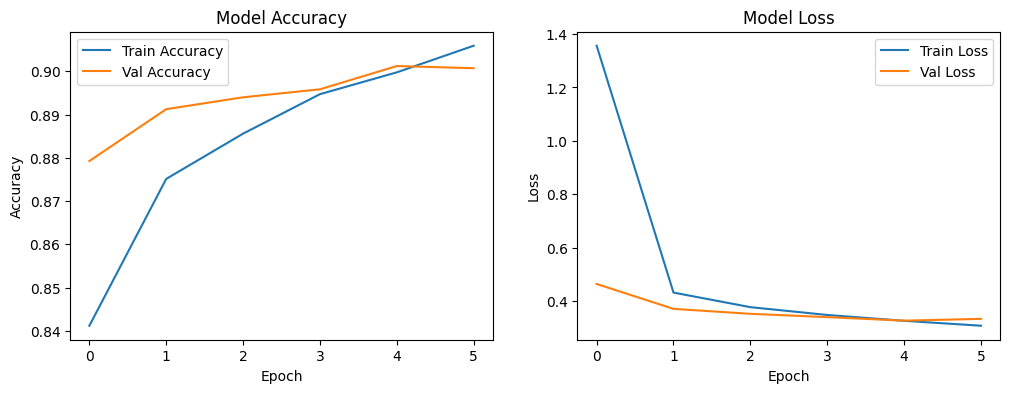

In [29]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [30]:
lstm_train_loss,lstm_train_acc=lstm_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {lstm_train_acc}")
print(f"train Loss: {lstm_train_loss}")

lstm_val_loss,lstm_val_acc=lstm_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {lstm_val_acc}")
print(f"Val Loss: {lstm_val_loss}")

lstm_test_loss,lstm_test_acc=lstm_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {lstm_test_acc}")
print(f"Test Loss: {lstm_test_loss}")



3000/3000 ━━━━━━━━━━━━━━━━━━━━ 427s 142ms/step - accuracy: 0.8814 - loss: 0.4573
Train Accuracy: 0.8813958168029785
train Loss: 0.4572538733482361
750/750 ━━━━━━━━━━━━━━━━━━━━ 104s 139ms/step - accuracy: 0.8799 - loss: 0.4670
Val Accuracy: 0.8799166679382324
Val Loss: 0.4670470356941223
238/238 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - accuracy: 0.8711 - loss: 0.4827
Test Accuracy: 0.871052622795105
Test Loss: 0.48269256949424744


In [31]:
lstm_pred=np.argmax(lstm_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,lstm_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 31s 123ms/step
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1900
           1       0.93      0.95      0.94      1900
           2       0.88      0.77      0.82      1900
           3       0.81      0.87      0.84      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600



In [1]:
comp_table['LSTM']=[lstm_train_acc,lstm_val_acc,lstm_test_acc,lstm_total_time,'']
comp_table

NameError: name 'lstm_train_acc' is not defined

### KEY_OBSERVATION COMPARISON: SRNN VS LSTM

In [ ]:
from IPython.display import Markdown, display
display(Markdown(f"""
- Accuracy Boost: The LSTM achieved a test accuracy of {round(lstm_test_acc,2)}%, compared to the SimpleRNN's {round(srnn_test_acc,2)}%. This is an  improvement of roughly 5%.

- Model Stability: Both the Models are stable from the perspective of training

- precision that is classifying class correctly has improved for all the classes while recall i.e correct prediction out of all the prediction in class 1 and 3 has improved while in class 0 and 1 is still the same.

- from time cost perspective LSTM took {lstm_total_time} while srnn took {srnn_total_time} which is very less hence srnn has less time complexity

"""))

### GRU

In [ ]:
class GRU_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      GRU(units=512,return_sequences=False,dropout=0.2),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_gru.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


grux_model=GRU_model()
hp=ks.HyperParameters()
gru_model=grux_model.build(hp)
print(gru_model.summary())

gru_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=GRU_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=GRU_model()
best_hp=tuner.get_best_hyperparameters()[0]
gru_model=hypermodel.build(best_hp)
gru_history=hypermodel.fit(best_hp,gru_model,x_train.values,y_train.values)


gru_end_time=time.time()
gru_total_time=(gru_end_time-gru_start_time)/60
print(f"total_time_taken: {gru_total_time}")

Trial 1 Complete [02h 12m 56s]
val_accuracy: 0.4348333477973938

Best val_accuracy So Far: 0.4348333477973938
Total elapsed time: 02h 12m 56s


In [ ]:
gru_train_loss,gru_train_acc=gru_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {gru_train_acc}")
print(f"train Loss: {gru_train_loss}")

gru_val_loss,gru_val_acc=gru_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {gru_val_acc}")
print(f"Val Loss: {gru_val_loss}")

gru_test_loss,gru_test_acc=gru_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {gru_test_acc}")
print(f"Test Loss: {gru_test_loss}")

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8920 - loss: 0.3340
Train Accuracy: 0.8959791660308838
train Loss: 0.32278361916542053
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8922 - loss: 0.3342
Val Accuracy: 0.8927500247955322
Val Loss: 0.3382483422756195
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8824 - loss: 0.3700
Test Accuracy: 0.8881579041481018
Test Loss: 0.35361248254776


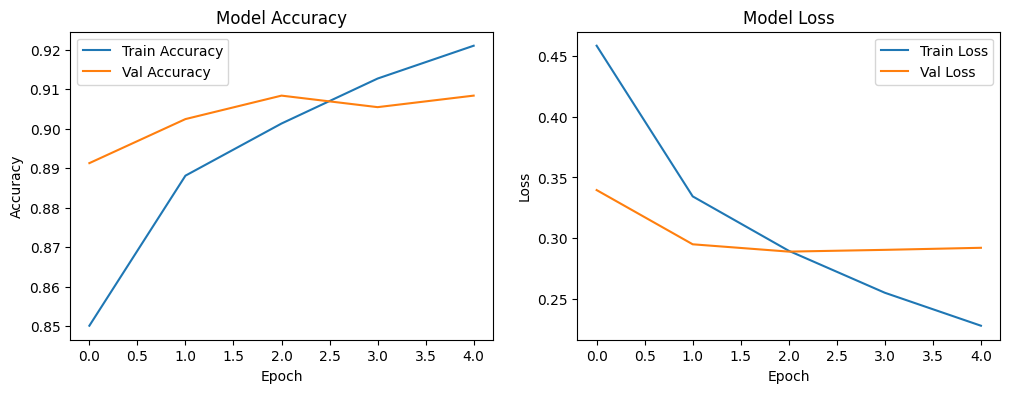

In [ ]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(gru_history.history['accuracy'], label='Train Accuracy')
plt.plot(gru_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], label='Train Loss')
plt.plot(gru_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [ ]:
gru_pred=np.argmax(gru_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,gru_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.93      0.86      0.90      1900
           1       0.92      0.98      0.95      1900
           2       0.85      0.84      0.84      1900
           3       0.86      0.87      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [ ]:
comp_table['GRU']=[gru_train_acc,gru_val_acc,gru_test_acc,gru_total_time,'']
comp_table

,metrics,SimpleRNN,LSTM,GRU
0,Training_Accuracy,0.707583,0.878375,0.895979
1,Validation_Accuracy,0.709708,0.877917,0.89275
2,Test_Accuracy,0.696053,0.871184,0.888158
3,Training_Time(Minutes),72.829653,11.638385,10.572474
4,key Observation,,,


### KEY OBSERVATION

- Accuracy: GRU achieved the highest test accuracy at 88.8%, slightly edgeing out the LSTM (87.1%) and significantly outperforming the SimpleRNN (69.6%)
  
- Balanced Class Performance: The classification report for the GRU shows exceptional balance. Every single class now has an F1-score between 0.84 and 0.95. The model is no longer "guessing" or favoring one class over another.

- GRU clocked in at 10.57 minutes, compared to LSTM's 11.6 minutes.GRUs have a simpler internal structure (two gates: reset and update) compared to LSTMs (three gates: input, forget, and output). This reduction in parameters allows the GRU to converge faster while maintaining—or in this case, improving—performance on your specific text dataset.

- Like the LSTM, the GRU curves are smooth, indicating stable weight updates and a well-tuned learning rate.

### BI-LSTM

In [ ]:
class BILSTM_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      Bidirectional(LSTM(units=512,return_sequences=False,dropout=0.2)),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_bilstm.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


bi_lstm_model=BILSTM_model()
hp=ks.HyperParameters()
bilstm_model=bi_lstm_model.build(hp)
print(bilstm_model.summary())

bilstm_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=BILSTM_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=BILSTM_model()
best_hp=tuner.get_best_hyperparameters()[0]
bilstm_model=hypermodel.build(best_hp)
bilstm_history=hypermodel.fit(best_hp,bilstm_model,x_train.values,y_train.values)


bilstm_end_time=time.time()
bilstm_total_time=(bilstm_end_time-bilstm_start_time)/60
print(f"total_time_taken: {bilstm_total_time}")

Trial 2 Complete [00h 03m 28s]
val_accuracy: 0.9009166955947876

Best val_accuracy So Far: 0.9087499976158142
Total elapsed time: 00h 13m 56s
Epoch 1/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8392 - loss: 0.5019
Epoch 1: val_accuracy improved from 0.01000 to 0.89333, saving model to best_bilstm.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 111s 20ms/step - accuracy: 0.8392 - loss: 0.5019 - val_accuracy: 0.8933 - val_loss: 0.3399
Epoch 2/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8878 - loss: 0.3367
Epoch 2: val_accuracy improved from 0.89333 to 0.89927, saving model to best_bilstm.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 108s 20ms/step - accuracy: 0.8878 - loss: 0.3367 - val_accuracy: 0.8993 - val_loss: 0.3131
Epoch 3/5
5399/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9028 - loss: 0.2837
Epoch 3: val_accuracy improved from 0.89927 to 0.90448, saving model to best_bilstm.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 108s 20ms/step - accuracy: 0.9028 - loss: 0.2837 

In [ ]:
bilstm_train_loss,bilstm_train_acc=bilstm_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {bilstm_train_acc}")
print(f"train Loss: {bilstm_train_loss}")

bilstm_val_loss,bilstm_val_acc=bilstm_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {bilstm_val_acc}")
print(f"Val Loss: {bilstm_val_loss}")

bilstm_test_loss,bilstm_test_acc=bilstm_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {bilstm_test_acc}")
print(f"Test Loss: {bilstm_test_loss}")




3000/3000 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - accuracy: 0.8933 - loss: 0.3270
Train Accuracy: 0.8975937366485596
train Loss: 0.31547465920448303
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8950 - loss: 0.3278
Val Accuracy: 0.893625020980835
Val Loss: 0.33437874913215637
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8827 - loss: 0.3573
Test Accuracy: 0.8882894515991211
Test Loss: 0.34454843401908875


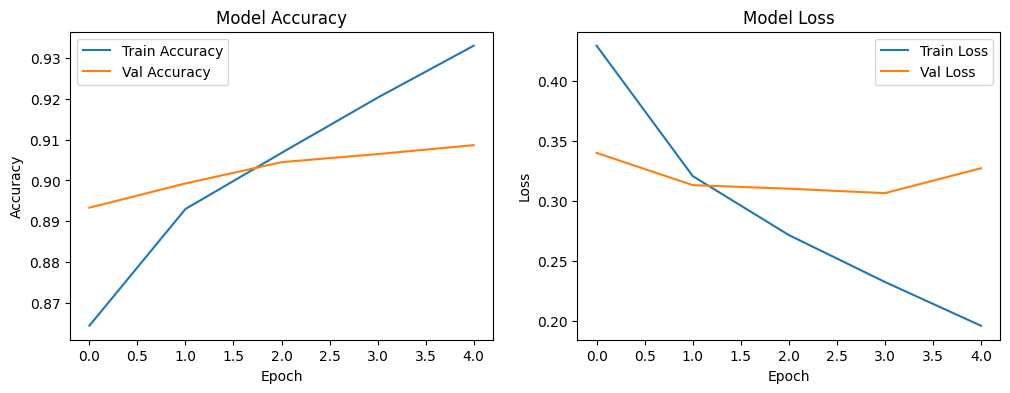

In [ ]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bilstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(bilstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bilstm_history.history['loss'], label='Train Loss')
plt.plot(bilstm_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [ ]:
bilstm_pred=np.argmax(bilstm_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,bilstm_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      1900
           1       0.94      0.97      0.95      1900
           2       0.85      0.85      0.85      1900
           3       0.83      0.89      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [ ]:
comp_table['BILSTM']=[bilstm_train_acc,bilstm_val_acc,bilstm_test_acc,bilstm_total_time,'']
comp_table

,metrics,SimpleRNN,LSTM,GRU,BILSTM
0,Training_Accuracy,0.707583,0.878375,0.895979,0.897594
1,Validation_Accuracy,0.709708,0.877917,0.89275,0.893625
2,Test_Accuracy,0.696053,0.871184,0.888158,0.888289
3,Training_Time(Minutes),72.829653,11.638385,10.572474,23.027933
4,key Observation,,,,


### KEY OBSERVATION

- While BiLSTMs are theoretically superior because they process text in both directions, for this specific dataset, the extra "backward" context didn't provide a significant boost over the GRU.
- At 23.02 minutes, the BiLSTM took more than double the time of the GRU (10.57m) and LSTM (11.63m).This is expected, as a BiLSTM essentially trains two separate hidden layers  and then concatenates them. this twice the work for a marginal gain in accuracy.
- Divergence: The Training Accuracy is climbing steeply toward 93%, but the Validation Accuracy is flattening out around 90%.

- Loss Curve: More concerning is the Model Loss graph—the Validation Loss (orange) has actually started to increase after epoch 3, while the Training Loss continues to drop.

### GRU with gradient clipping

In [ ]:
class GRUgc_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      GRU(units=512,return_sequences=False,dropout=0.2),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    clip_norm=hp.Float('clipnorm',min_value=0.5,max_value=1.0,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate,clipnorm=clip_norm), #Applying Gradient clipping
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_grugc.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


grugcx_model=GRUgc_model()
hp=ks.HyperParameters()
grugc_model=grugcx_model.build(hp)
print(grugc_model.summary())

grugc_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=GRUgc_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=GRUgc_model()
best_hp=tuner.get_best_hyperparameters()[0]
grugc_model=hypermodel.build(best_hp)
grugc_history=hypermodel.fit(best_hp,gru_model,x_train.values,y_train.values)


grugc_end_time=time.time()
grugc_total_time=(grugc_end_time-grugc_start_time)/60
print(f"total_time_taken: {grugc_total_time}")

Trial 2 Complete [00h 01m 13s]
val_accuracy: 0.902999997138977

Best val_accuracy So Far: 0.902999997138977
Total elapsed time: 00h 06m 02s
Epoch 1/15
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9068 - loss: 0.2717
Epoch 1: val_accuracy improved from 0.01000 to 0.91918, saving model to best_grugc.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9068 - loss: 0.2717 - val_accuracy: 0.9192 - val_loss: 0.2453
Epoch 2/15
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9119 - loss: 0.2548
Epoch 2: val_accuracy improved from 0.91918 to 0.92028, saving model to best_grugc.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9119 - loss: 0.2548 - val_accuracy: 0.9203 - val_loss: 0.2433
Epoch 3/15
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9143 - loss: 0.2481
Epoch 3: val_accuracy did not improve from 0.92028
208/208 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9143 - loss: 0.2482 - val_accuracy: 0.9201 - val_loss: 0.2425
Epoch 4/15
207

In [ ]:
grugc_train_loss,grugc_train_acc=grugc_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {grugc_train_acc}")
print(f"train Loss: {grugc_train_loss}")

grugc_val_loss,grugc_val_acc=grugc_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {grugc_val_acc}")
print(f"Val Loss: {grugc_val_loss}")

grugc_test_loss,grugc_test_acc=grugc_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {grugc_test_acc}")
print(f"Test Loss: {grugc_test_loss}")

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.2585 - loss: 1.3866
Train Accuracy: 0.2600937485694885
train Loss: 1.3867332935333252
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2559 - loss: 1.3874
Val Accuracy: 0.2590000033378601
Val Loss: 1.3853693008422852
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2519 - loss: 1.3890
Test Accuracy: 0.2605263292789459
Test Loss: 1.382683277130127


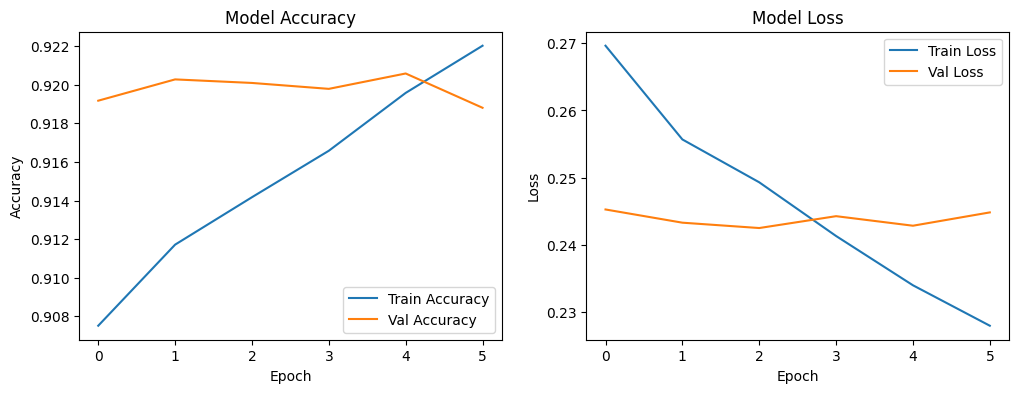

In [ ]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(grugc_history.history['accuracy'], label='Train Accuracy')
plt.plot(grugc_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(grugc_history.history['loss'], label='Train Loss')
plt.plot(grugc_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [ ]:
grugc_pred=np.argmax(grugc_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,grugc_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.25      0.29      0.27      1900
           1       0.58      0.06      0.11      1900
           2       0.27      0.58      0.36      1900
           3       0.21      0.10      0.14      1900

    accuracy                           0.26      7600
   macro avg       0.32      0.26      0.22      7600
weighted avg       0.32      0.26      0.22      7600



In [ ]:
comp_table['GRUgc']=[grugc_train_acc,grugc_val_acc,grugc_test_acc,grugc_total_time,'']
comp_table

,metrics,SimpleRNN,LSTM,GRU,BILSTM,GRUgc
0,Training_Accuracy,0.707583,0.878375,0.895979,0.897594,0.260094
1,Validation_Accuracy,0.709708,0.877917,0.89275,0.893625,0.259
2,Test_Accuracy,0.696053,0.871184,0.888158,0.888289,0.260526
3,Training_Time(Minutes),72.829653,11.638385,10.572474,23.027933,6.937014
4,key Observation,,,,,


### KEY OBSERVATION

Without Gradient Clipping (GRU)
    
    - Performance: This model was highly successful, reaching nearly 89% test accuracy. It successfully captured the linguistic patterns of the dataset.
    
    - Convergence: The model converged to a stable, high-accuracy state. Based on your earlier plots, the loss curve was smooth, suggesting that for this specific task, the gradients were already well-behaved and did not "explode."
    
    - Effectiveness: The "natural" gradients were large enough to allow the model to learn complex relationships between words and labels.

With Gradient Clipping (GRUgc)

    - Performance: This model failed to learn, performing at roughly 26% accuracy, which is near-random guessing for a 4-class problem.

    - Convergence: While the training time was faster (6.93 minutes), it was essentially a "fast-track to failure." The model never moved past the initial baseline performance.

    - Suffocation Effect: In your case, the gradient clipping acted as a "bottleneck" rather than a safety net. Because the clipnorm was likely set too low, the weight updates were so small that the model could not navigate the loss landscape to find a better solution.


yes, it made the training "stable" in the sense that there were no erratic spikes in loss, but it was unproductive stability.

    - Stability vs. Learning: Without clipping, the GRU was already stable and achieved high accuracy. With clipping, the training became "dead-flat"—it was so stable that it never moved.

    - Conclusion: For your specific dataset and architecture, gradient clipping was not beneficial. It transformed a high-performing model into a non-functional one because the gradients needed to reach 89% accuracy were "chopped off" by the clipping threshold.

1. Which model performed best?
 - The GRU (standard) model performed the best overall. It achieved a Test Accuracy of 88.82%, which was marginally higher than the standard LSTM and Bi-LSTM models while maintaining superior computational efficiency.

2. Did LSTM or GRU perform better than Simple RNN?
 - Yes, significantly. The Simple RNN achieved a test accuracy of only 69.61%, whereas the LSTM and GRU both crossed the 87% mark. This represents a nearly 20% improvement in accuracy. The gated architectures of LSTM and GRU successfully addressed the Vanishing Gradient problem, allowing the model to capture long-term dependencies in the text that the Simple RNN could not.

3. Did Bi-LSTM improve classification performance?
 - No. While the Bi-LSTM is theoretically more powerful due to processing sequences in both directions, it achieved a test accuracy of 88.83%, which is essentially identical to the standard GRU (88.82%). In this specific dataset, the additional "backward" context did not provide a meaningful boost in performance, suggesting that the primary features for classification were identifiable through forward processing alone.

4. Which model trained faster?
 - The GRU model was the fastest successful model, training in 10.57 minutes. The GRUgc (with clipping) was technically faster at 6.94 minutes, but it failed to learn (26% accuracy). Among the high-performing models, the GRU was twice as fast as the Bi-LSTM (23.03 minutes) and slightly faster than the LSTM (11.64 minutes).

5. Which model would you recommend for this dataset and why?
 - I recommend the Standard GRU for this dataset.

    - Efficiency: It offers the best accuracy-to-time ratio, reaching the performance ceiling of 89% in the shortest amount of time.

    - Simplicity: It has fewer parameters than an LSTM or Bi-LSTM, making it less prone to overfitting on smaller text samples.

 - Stability: As seen in your results, the standard GRU is naturally stable for this task; adding complex constraints like gradient clipping or bidirectional layers only increased training time or introduced failure points without improving the final classification result.

In [ ]:

str.punctuation